In [1]:
!pip install pennylane
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 96.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:

In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import time
import math

# PennyLane imports
import pennylane as qml
from pennylane import numpy as np_qml

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [49]:
# --- Dataset Configuration ---
DATA_DIR = "/kaggle/input/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
RANDOM_SEED = 42
NUM_WORKERS = 2

# --- Quantum Configuration ---
N_QUBITS = 5  # Number of qubits
N_LAYERS = 2  # Number of quantum layers

print("Checking dataset directory...")
if not os.path.exists(DATA_DIR):
    print(" DATA_DIR does not exist:", DATA_DIR)
else:
    print(" Found DATA_DIR:", DATA_DIR)

# --- Data Transformations and Loading ---
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Checking dataset directory...
 Found DATA_DIR: /kaggle/input/BreaKHis_v1/BreaKHis_v1/histology_slides/breast


In [4]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
class_names = full_dataset.classes
print("Classes:", class_names)
print("Total images:", len(full_dataset))

Classes: ['benign', 'malignant']
Total images: 7909


In [5]:
# Split dataset
train_size = int((1.0 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)

print(f"Split -> Train: {len(train_dataset)}  Val: {len(val_dataset)}")

Split -> Train: 6327  Val: 1582


In [6]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import MobileNet_V3_Small_Weights
import pennylane as qml

In [50]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=1):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(self.dev, interface="torch")
        def circuit(inputs, weights):
            # ✅ Normalize per-sample for amplitude embedding
            inputs = inputs / torch.norm(inputs, dim=1, keepdim=True)
            qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=False)

            # --- Variational block ---
            for layer in range(n_layers):
                # Entanglement
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
                # Rotations
                for i in range(n_qubits):
                    qml.RX(weights[layer, i, 0], wires=i)
                    qml.RY(weights[layer, i, 1], wires=i)
                    qml.RZ(weights[layer, i, 2], wires=i)

            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

    def forward(self, x):
        device = x.device
        batch_size = x.shape[0]
        n_features = 2 ** self.n_qubits

        # Match size
        if x.shape[1] != n_features:
            if x.shape[1] < n_features:
                pad_size = n_features - x.shape[1]
                pad = torch.zeros(batch_size, pad_size, device=device)
                x = torch.cat([x, pad], dim=1)
            else:
                x = x[:, :n_features]

        return self.qlayer(x)


In [59]:
def make_grover_qnode(n_qubits, n_amp):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch")
    def grover_classifier(inputs, oracle_weights):
        # --- Amplitude Embedding ---
        # Normalize and embed the 32D vector into 2^5 = 32 amplitudes
        norm_inputs = inputs / torch.norm(inputs, dim=-1, keepdim=True)
        qml.AmplitudeEmbedding(features=norm_inputs, wires=range(n_qubits), normalize=False)

        # --- Grover Iteration ---
        # Example oracle based on parameterized rotations
        for i in range(n_qubits):
            qml.RZ(oracle_weights[i], wires=i)

        # Diffusion operator (inversion about the mean)
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        for i in range(n_qubits):
            qml.X(wires=i)
        qml.MultiControlledX(wires=list(range(n_qubits)))  # ✅ fixed line
        for i in range(n_qubits):
            qml.X(wires=i)

        for i in range(n_qubits):
            qml.Hadamard(wires=i)

        # --- Measurement ---
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return grover_classifier

In [60]:
class GroverClassifier(nn.Module):
    def __init__(self, n_qubits=5, n_classes=4):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_amp = 2 ** n_qubits  # number of features the amplitude embedding can encode

        # Create QNode
        qnode = make_grover_qnode(n_qubits, self.n_amp)
        weight_shapes = {"oracle_weights": (n_qubits,)}  # learnable Grover oracle parameters

        # Quantum layer
        self.grover_layer = qml.qnn.TorchLayer(qnode, weight_shapes)

        # Map quantum expectations -> class logits
        self.fc = nn.Sequential(
            nn.Linear(n_qubits, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.grover_layer(x)
        return self.fc(x)

In [61]:
class HQCNN_MobileNetV3_Quantum_Grover(nn.Module):
    def __init__(self, num_classes, embed_dim=32, use_quantum=True,
                 freeze_backbone=True, n_qubits=4, n_layers=1):
        super().__init__()
        self.use_quantum = use_quantum
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Backbone
        self.backbone = models.mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        feat_dim = self.backbone.classifier[0].in_features
        self.backbone.classifier = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            print(f"Backbone frozen - {sum(p.numel() for p in self.backbone.parameters()):,} params frozen")

        # Projection
        self.proj = nn.Linear(feat_dim, n_qubits if use_quantum else embed_dim)

        if use_quantum:
            self.quantum_layer = QuantumLayer(n_qubits=n_qubits, n_layers=n_layers)
            self.quantum_post = nn.Linear(n_qubits, embed_dim // 2)

            self.classical_branch = nn.Sequential(
                nn.Linear(feat_dim, embed_dim // 2),
                nn.BatchNorm1d(embed_dim // 2),
                nn.ReLU(inplace=True),
                nn.Dropout(0.2)
            )
            effective_dim = embed_dim
        else:
            effective_dim = embed_dim

        # Replace Sequential Classifier with Grover
        self.grover_head = GroverClassifier(n_qubits=5, n_classes=num_classes)

        self._print_params()

    def _print_params(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

    def forward(self, x):
        feat = self.backbone(x)
        feat_proj = self.proj(feat)

        if self.use_quantum:
            quantum_out = self.quantum_layer(feat_proj)
            quantum_feat = self.quantum_post(quantum_out)

            classical_feat = self.classical_branch(feat)

            combined = torch.cat([quantum_feat, classical_feat], dim=1)
        else:
            combined = feat_proj

        out = self.grover_head(combined)
        return out

In [62]:
def count_parameters(model):
    """Count total and trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [63]:
def measure_inference_time(model, data_loader, device, num_batches=5):
    """Measure average inference time"""
    model.eval()
    times = []
    
    with torch.no_grad():
        for i, (inputs, _) in enumerate(data_loader):
            if i >= num_batches:
                break
            
            inputs = inputs.to(device)
            
            # Warm up GPU
            if i == 0:
                _ = model(inputs)
                torch.cuda.synchronize() if device.type == 'cuda' else None
            
            start_time = time.time()
            _ = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.time()
            
            times.append(end_time - start_time)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    return avg_time, std_time

In [64]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
               device, num_epochs=10, save_path='best_hqcnn_quantum.pth'):
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    model.to(device)
    
    for epoch in range(num_epochs):
        t0 = time.time()
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = running_corrects.double().item() / total
        
        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                _, preds = torch.max(outputs, 1)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                val_total += labels.size(0)
        
        val_loss = val_running_loss / val_total
        val_acc = val_running_corrects.double().item() / val_total
        
        # Update learning rate
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
        
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} '
              f'- Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} - LR: {current_lr:.6f} - Time: {elapsed:.1f}s')
    
    return history

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model_quantum = HQCNN_MobileNetV3_Quantum_Grover(
    num_classes=len(class_names), 
    use_quantum=True,
    freeze_backbone=False
).to(device)

quantum_total, quantum_trainable = count_parameters(model_quantum)

print(f"Quantum Model:")
print(f"  Total parameters: {quantum_total:,}")
print(f"  Trainable parameters: {quantum_trainable:,}")

Device: cuda
Total parameters: 939,191
Trainable parameters: 939,191
Quantum Model:
  Total parameters: 939,191
  Trainable parameters: 939,191


In [66]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer_quantum = torch.optim.AdamW(model_quantum.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_quantum = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_quantum, patience=2, factor=0.5)

NUM_EPOCHS = 10

print(f"\n=== TRAINING QUANTUM MODEL ===")
history_quantum = train_model(
    model_quantum, train_loader, val_loader, criterion, optimizer_quantum, scheduler_quantum,
    device, num_epochs=NUM_EPOCHS, save_path='best_hqcnn_quantum.pth'
)


=== TRAINING QUANTUM MODEL ===
Epoch 1/10 - Train Loss: 0.5753 Train Acc: 0.7594 - Val Loss: 0.4204 Val Acc: 0.8761 - LR: 0.000100 - Time: 110.5s
Epoch 2/10 - Train Loss: 0.3316 Train Acc: 0.9025 - Val Loss: 0.2175 Val Acc: 0.9406 - LR: 0.000100 - Time: 68.7s
Epoch 3/10 - Train Loss: 0.2129 Train Acc: 0.9336 - Val Loss: 0.1680 Val Acc: 0.9494 - LR: 0.000100 - Time: 69.1s
Epoch 4/10 - Train Loss: 0.1631 Train Acc: 0.9472 - Val Loss: 0.1268 Val Acc: 0.9564 - LR: 0.000100 - Time: 69.0s
Epoch 5/10 - Train Loss: 0.1280 Train Acc: 0.9600 - Val Loss: 0.1080 Val Acc: 0.9659 - LR: 0.000100 - Time: 68.5s
Epoch 6/10 - Train Loss: 0.1032 Train Acc: 0.9663 - Val Loss: 0.0885 Val Acc: 0.9709 - LR: 0.000100 - Time: 71.7s
Epoch 7/10 - Train Loss: 0.0866 Train Acc: 0.9728 - Val Loss: 0.0820 Val Acc: 0.9735 - LR: 0.000100 - Time: 71.1s
Epoch 8/10 - Train Loss: 0.0756 Train Acc: 0.9760 - Val Loss: 0.0876 Val Acc: 0.9671 - LR: 0.000100 - Time: 70.0s
Epoch 9/10 - Train Loss: 0.0688 Train Acc: 0.9795 - Val

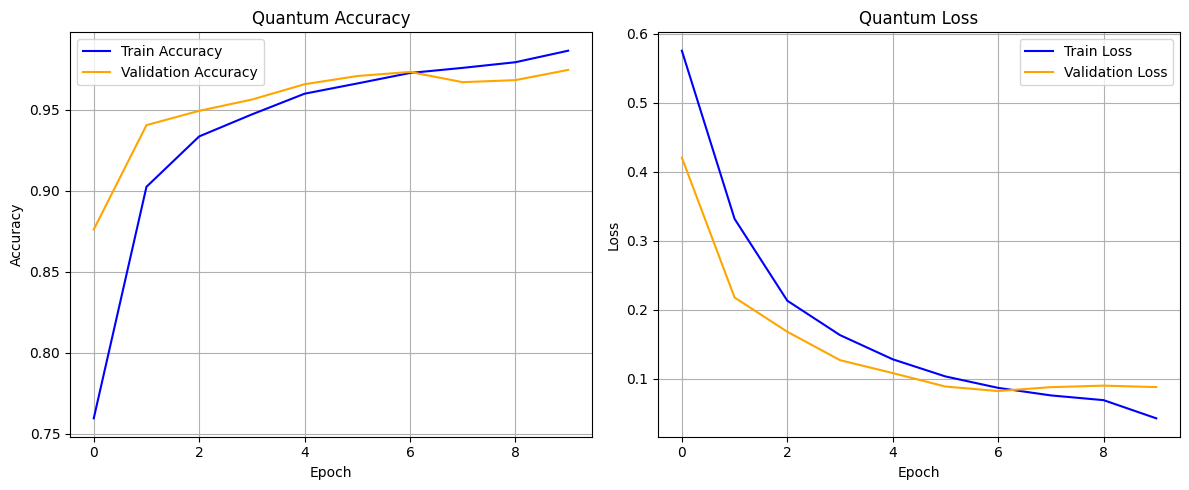

In [67]:
def plot_quantum(history_quantum):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(history_quantum['train_acc'], label='Train Accuracy', color='blue')
    ax1.plot(history_quantum['val_acc'], label='Validation Accuracy', color='orange')
    ax1.set_title('Quantum Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history_quantum['train_loss'], label='Train Loss', color='blue')
    ax2.plot(history_quantum['val_loss'], label='Validation Loss', color='orange')
    ax2.set_title('Quantum Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_quantum(history_quantum)

In [68]:
print(f"\n=== INFERENCE TIME COMPARISON ===")

model_quantum.load_state_dict(torch.load('best_hqcnn_quantum.pth', map_location=device))
quantum_time, quantum_std = measure_inference_time(model_quantum, val_loader, device)
print(f"Quantum Model - Avg inference time: {quantum_time:.4f}s (±{quantum_std:.4f}s)")


=== INFERENCE TIME COMPARISON ===
Quantum Model - Avg inference time: 0.0384s (±0.0031s)


In [69]:
def evaluate_model(model, data_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    
    return all_labels, all_preds

print(f"\n=== FINAL EVALUATION ===")

# Quantum model evaluation
all_labels_q, all_preds_q = evaluate_model(model_quantum, val_loader, device, class_names)
print('\nQuantum Model - Classification Report:')
print(classification_report(all_labels_q, all_preds_q, target_names=class_names))


=== FINAL EVALUATION ===

Quantum Model - Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.95      0.96       502
   malignant       0.98      0.99      0.98      1080

    accuracy                           0.97      1582
   macro avg       0.97      0.97      0.97      1582
weighted avg       0.97      0.97      0.97      1582



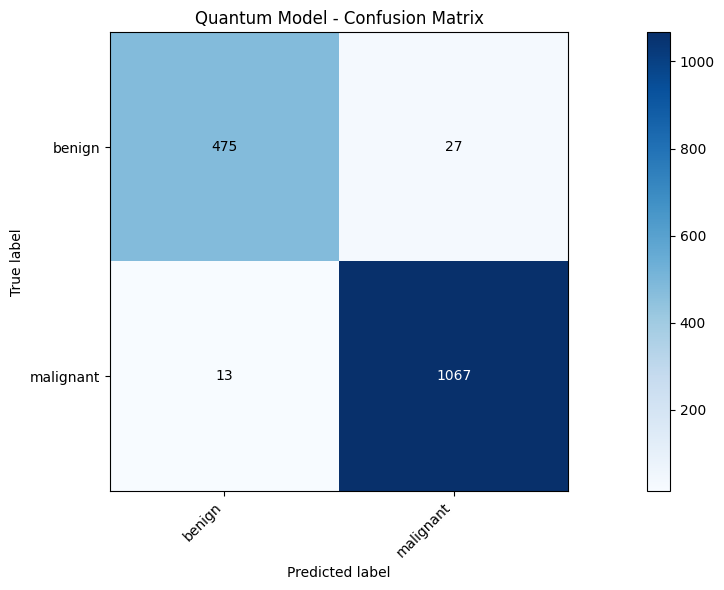


=== SUMMARY ===
Best Validation Accuracy:
  Quantum Model: 0.9747


In [70]:
# Confusion matrices
fig, (ax1) = plt.subplots(1, figsize=(16, 6))

# Quantum confusion matrix
cm_q = confusion_matrix(all_labels_q, all_preds_q)
im1 = ax1.imshow(cm_q, interpolation='nearest', cmap=plt.cm.Blues)
ax1.set_title('Quantum Model - Confusion Matrix')
ax1.figure.colorbar(im1, ax=ax1)
ticks = np.arange(len(class_names))
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_xticklabels(class_names, rotation=45, ha='right')
ax1.set_yticklabels(class_names)

thresh = cm_q.max() / 2.
for i in range(cm_q.shape[0]):
    for j in range(cm_q.shape[1]):
        ax1.text(j, i, format(cm_q[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_q[i, j] > thresh else 'black')

ax1.set_ylabel('True label')
ax1.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"Best Validation Accuracy:")
print(f"  Quantum Model: {max(history_quantum['val_acc']):.4f}")